In [116]:
import numpy as np
import pandas as pd
from numba import njit
import vectorbt as vbt
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns

from utils.KrakenHistoricalData import KrakenHistoricalData


In [117]:
# ========= 1. Data =========
interval = '4h'
# tickers = ["BTC-USD", "ETH-USD", "DOGE-USD","LTC-USD","XRP-USD"]
# data = vbt.YFData.download(tickers, start="2025-01-01", interval=interval)
# close = data.get("Close").astype(np.float64).copy(deep=True)
# high = data.get("High").astype(np.float64).copy(deep=True)
# low = data.get("Low").astype(np.float64).copy(deep=True)

#
tickers = ["BTC","ETH","LTC","DOGE","XRP"]
k = KrakenHistoricalData()
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
start = pd.to_datetime("2025-01-30").tz_localize('UTC')
data_df = k.get_ohlcv_df(tickers,interval=interval)
close = data_df.loc[start:end].xs('close', axis=1, level=1)
high = data_df.loc[start:end].xs('high', axis=1, level=1)
low = data_df.loc[start:end].xs('low', axis=1, level=1)
open = data_df.loc[start:end].xs('open', axis=1, level=1)
print(close.head())




                                     BTC          ETH         LTC      DOGE  \
2025-01-30 00:00:00+00:00  105149.898438  3200.000000  121.070000  0.332904   
2025-01-30 04:00:00+00:00  105115.296875  3191.020020  127.339996  0.331104   
2025-01-30 08:00:00+00:00  105338.601562  3223.699951  128.800003  0.332381   
2025-01-30 12:00:00+00:00  105572.000000  3255.709961  131.160004  0.336594   
2025-01-30 16:00:00+00:00  105750.203125  3272.080078  128.610001  0.334805   

                               XRP  
2025-01-30 00:00:00+00:00  3.12239  
2025-01-30 04:00:00+00:00  3.10905  
2025-01-30 08:00:00+00:00  3.10202  
2025-01-30 12:00:00+00:00  3.12122  
2025-01-30 16:00:00+00:00  3.13055  


In [118]:
# ========= 2. Signal Data Comparison =========

def entry_signals(close, high, low):
    print(f"\npandas_ta")
    sar_pandas_ta = vbt.pandas_ta('psar').run(high, low, close=close, acceleration=0.02, maximum=0.2)
    print(sar_pandas_ta.psarl.tail())
    sar_buy = sar_pandas_ta.psarl_below(close)

    adx_pandas_ta = vbt.pandas_ta('adx').run(high, low, close, length=14)
    dmp_cross = adx_pandas_ta.dmp_above(adx_pandas_ta.dmn)
    adx_threshold_cross = adx_pandas_ta.adx_above(25)
    adx_buy = dmp_cross & adx_threshold_cross
    # adx_buy.columns = buy2.columns.droplevel(0)
    print(f"\ndmp > dmn")
    print(adx_buy.tail())

        # If they're DataFrames with different column structures, extract the values
    if isinstance(sar_buy, pd.DataFrame) and isinstance(adx_buy, pd.DataFrame):
        # Align on index, then perform element-wise AND
        entries = pd.DataFrame(
            sar_buy.values & adx_buy.values,
            index=sar_buy.index,
            columns=sar_buy.columns
        )
    else:
        # If they're Series or have matching structure
        entries = sar_buy & adx_buy
    return entries


def exit_signals(close, high, low):
    ce = vbt.pandas_ta('chandelier_exit').run(high, low, close, multiplier=3)
    print(f"\nChandelier Exit")
    ce_exit = ce.chdlrextl

    print(ce_exit.tail())
    ce_signal = ce_exit.values > low
    # ce_signal = ce.chdlrextd > 0

    print(ce_signal.tail())
    return ce_signal, ce_exit


entries = entry_signals(close, high, low)
exits, ce_exit = exit_signals(close, high, low)

print(f"\nentries")
print(entries.tail())






pandas_ta
                                     BTC          ETH         LTC      DOGE  \
2025-09-29 08:00:00+00:00  109381.096879  3912.824330  103.823492  0.224659   
2025-09-29 12:00:00+00:00  109621.401004  3922.321748  104.226273  0.225181   
2025-09-29 16:00:00+00:00  110085.150747  3939.455236  104.697194  0.225683   
2025-09-29 20:00:00+00:00  110602.800470  3955.560715  105.102187  0.226165   
2025-09-30 00:00:00+00:00  111136.284186  3978.129451  105.450480  0.226935   

                                XRP  
2025-09-29 08:00:00+00:00  2.722871  
2025-09-29 12:00:00+00:00  2.733817  
2025-09-29 16:00:00+00:00  2.749383  
2025-09-29 20:00:00+00:00  2.763703  
2025-09-30 00:00:00+00:00  2.776878  

dmp > dmn
adx_length                   14                           
                            BTC   ETH    LTC   DOGE    XRP
2025-09-29 08:00:00+00:00  True  True  False  False  False
2025-09-29 12:00:00+00:00  True  True   True   True  False
2025-09-29 16:00:00+00:00  True  True  

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1459 entries, 2025-01-30 00:00:00+00:00 to 2025-09-30 00:00:00+00:00
Freq: 4h
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   (3, BTC)   1445 non-null   float64
 1   (3, ETH)   1445 non-null   float64
 2   (3, LTC)   1445 non-null   float64
 3   (3, DOGE)  1445 non-null   float64
 4   (3, XRP)   1445 non-null   float64
dtypes: float64(5)
memory usage: 68.4 KB
None


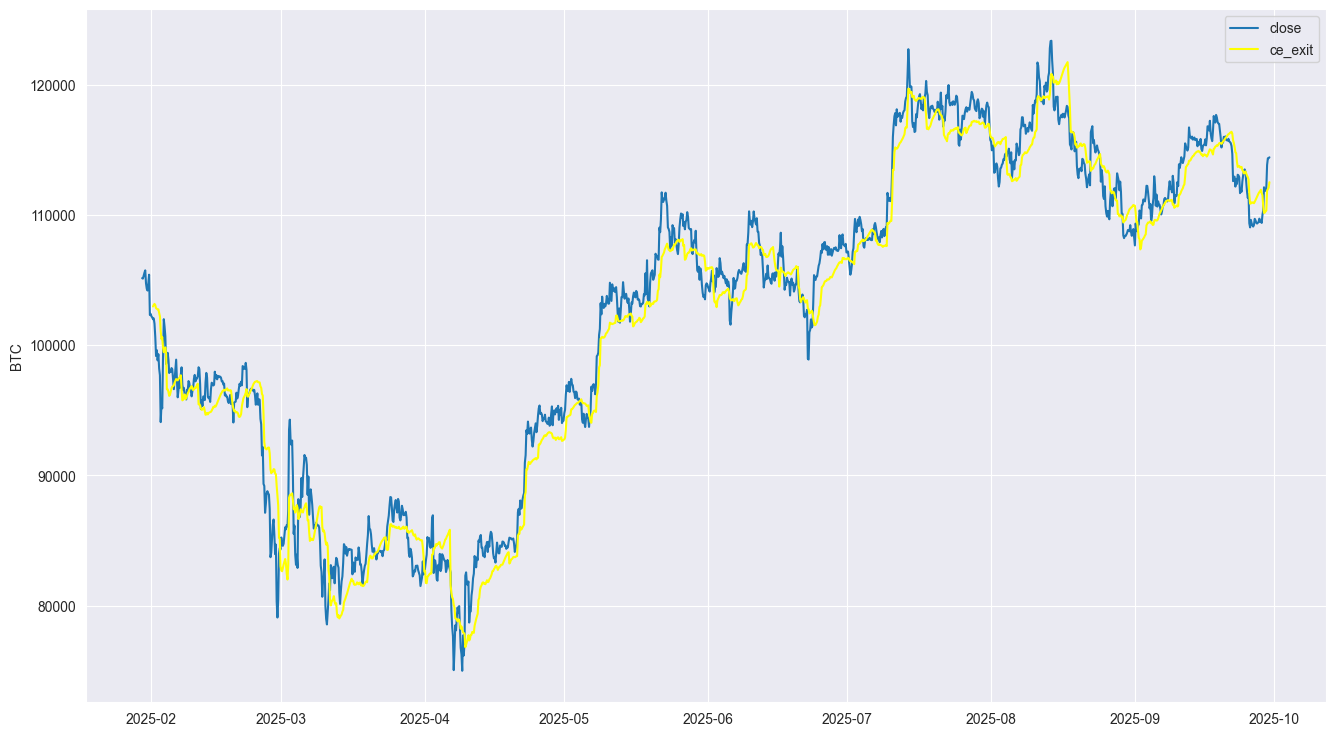

In [119]:
# ce_data = ce_exit.xs(tickers[0], axis=1, level='symbol').squeeze()  # Convert to Series
print(ce_exit.info())
ce_data = ce_exit.xs(tickers[0], axis=1,level=1).squeeze()
exit_line = (ce_data > low[tickers[0]]).squeeze()

fig, ax = plt.subplots(figsize=(16, 9))
sns.lineplot(data=close[tickers[0]], ax=ax, label='close')
sns.lineplot(data=ce_data, color='yellow', ax=ax, label='ce_exit')
# Create secondary y-axis and plot on it using matplotlib
# ax2 = ax.twinx()
# ax2.plot(exit_line.index, exit_line.values, color='red', label='exit_line', linestyle='--', alpha=0.2)
# ax2.set_ylabel('Exit Line')
#
# # Combine legends from both axes
# lines1, labels1 = ax.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.show()

In [120]:
pf = vbt.Portfolio.from_signals(close,
                                entries=entries,
                                exits=exits,
                                size=1,
                                size_type='percent',
                                direction='longonly',
                                sl_stop=0.1,
                                sl_trail=True,
                                freq=interval,
                                fees=0.004,
                                init_cash=1000,
                                )

In [121]:
pf_btc = pf[pf.wrapper.columns[0]]

stats_df = pd.DataFrame()
for col in pf.wrapper.columns:
    pf_col = pf[col]
    stats_df = pd.concat([stats_df, pf_col.stats()], axis=1)

print(stats_df.to_string())



                                                  BTC                        ETH                        LTC                       DOGE                        XRP
Start                       2025-01-30 00:00:00+00:00  2025-01-30 00:00:00+00:00  2025-01-30 00:00:00+00:00  2025-01-30 00:00:00+00:00  2025-01-30 00:00:00+00:00
End                         2025-09-30 00:00:00+00:00  2025-09-30 00:00:00+00:00  2025-09-30 00:00:00+00:00  2025-09-30 00:00:00+00:00  2025-09-30 00:00:00+00:00
Period                              243 days 04:00:00          243 days 04:00:00          243 days 04:00:00          243 days 04:00:00          243 days 04:00:00
Start Value                                    1000.0                     1000.0                     1000.0                     1000.0                     1000.0
End Value                                  958.378926                1172.924187                 623.676955                1347.472409                1017.140658
Total Return [%]            

In [122]:

pf[pf.wrapper.columns[3]].plot(width=1200, height=1900).show()